In [1]:
import platform
import matplotlib.pyplot as plt
from matplotlib import rcParams

if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False

In [3]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

classifier = pipeline(
    task="image-classification",
    model="google/vit-base-patch16-224",
    device=device,
)

print(f"✅ ViT 모델 로드 완료 (실행 장치: {'GPU' if device == 0 else 'CPU'})")

C:\Users\6-112\Desktop\빅데이터분석프로그래밍\20232500 박주원\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 9743.09it/s]


✅ ViT 모델 로드 완료 (실행 장치: CPU)


In [7]:
from PIL import Image

img = Image.open("hw/image/1.jpg").convert("RGB")
result = classifier(img, top_k=5)

for r in result:
    print(f"{r['label']:40s}  →  {r['score']*100:.2f}%")

llama                                     →  56.47%
Arabian camel, dromedary, Camelus dromedarius  →  42.83%
ostrich, Struthio camelus                 →  0.17%
gazelle                                   →  0.05%
bison                                     →  0.02%


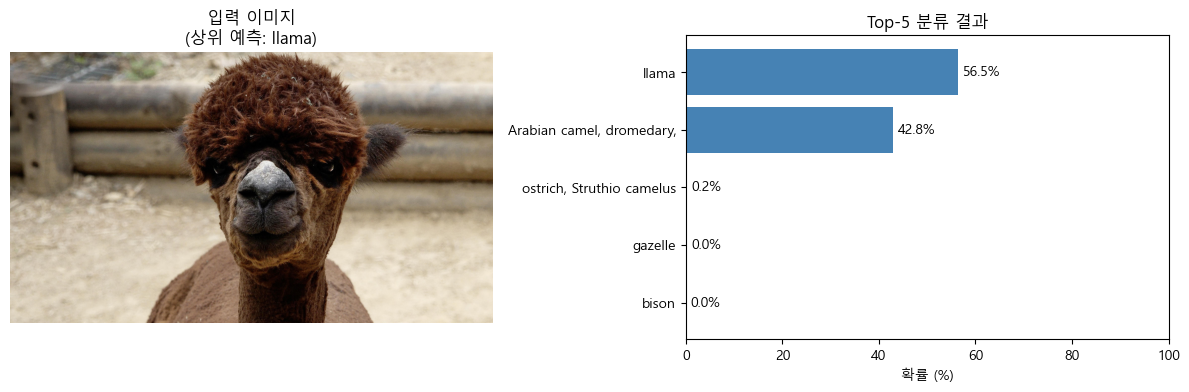

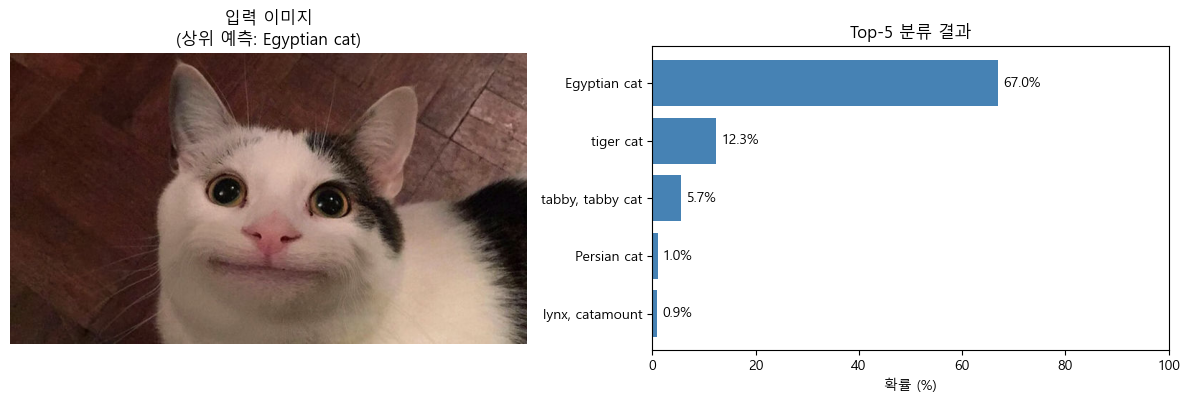

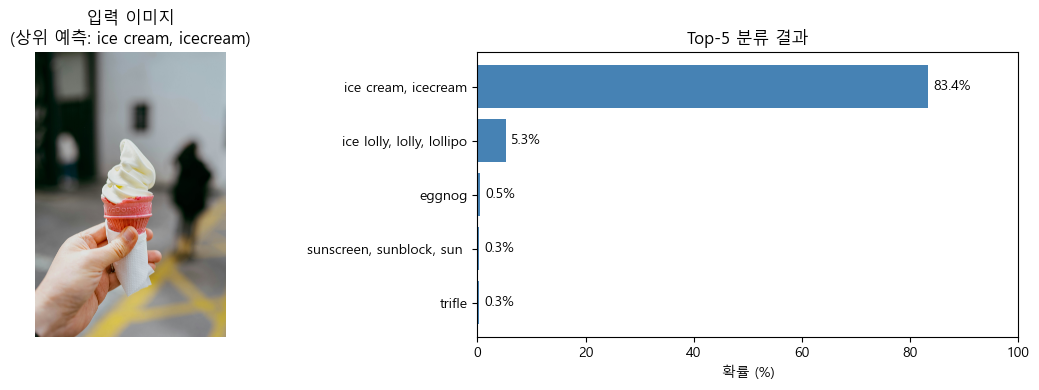

In [11]:
def classify_and_show(image_or_path):
    """이미지(경로 또는 PIL) + 분류 결과 막대그래프를 나란히 표시"""
    if isinstance(image_or_path, str):
        image = Image.open(image_or_path).convert("RGB")
    else:
        image = image_or_path.convert("RGB")

    result = classifier(image, top_k=5)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title(f"입력 이미지\n(상위 예측: {result[0]['label']})")
    axes[0].axis("off")

    labels = [r["label"][:25] for r in result]
    scores = [r["score"] * 100 for r in result]

    axes[1].barh(range(5), scores[::-1], color="steelblue")
    axes[1].set_yticks(range(5))
    axes[1].set_yticklabels(labels[::-1])
    axes[1].set_xlabel("확률 (%)")
    axes[1].set_title("Top-5 분류 결과")
    axes[1].set_xlim(0, 100)
    for i, s in enumerate(scores[::-1]):
        axes[1].text(s + 1, i, f"{s:.1f}%", va="center")

    plt.tight_layout(); plt.show()
    return result

# 강사 샘플 시연
for fname in ["1.jpg", "2.jpg", "3.jpg"]:
    path = f"hw/image/{fname}"
    try:
        classify_and_show(path)
    except FileNotFoundError:
        print(f"⚠️ {path} 없음 — image/README.md 참고")


현재 이미지: hw/image/1.jpg


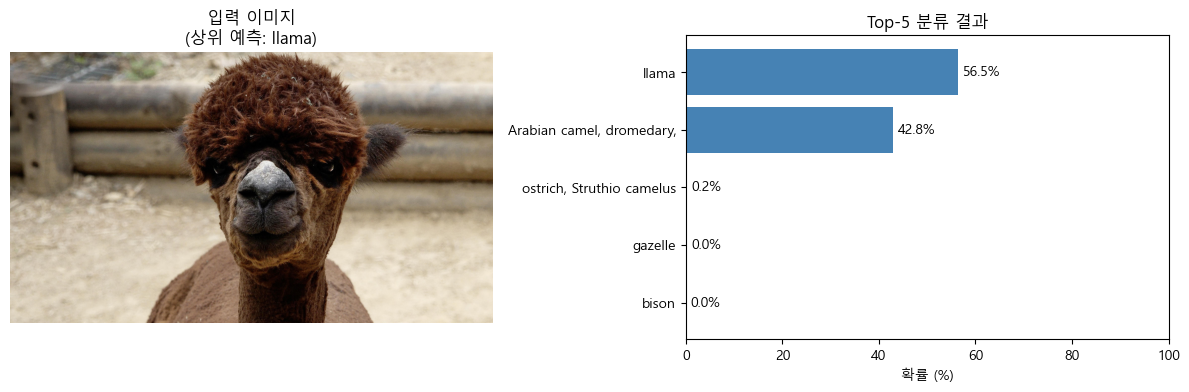

결과: llama(56.5%)

현재 이미지: hw/image/2.jpg


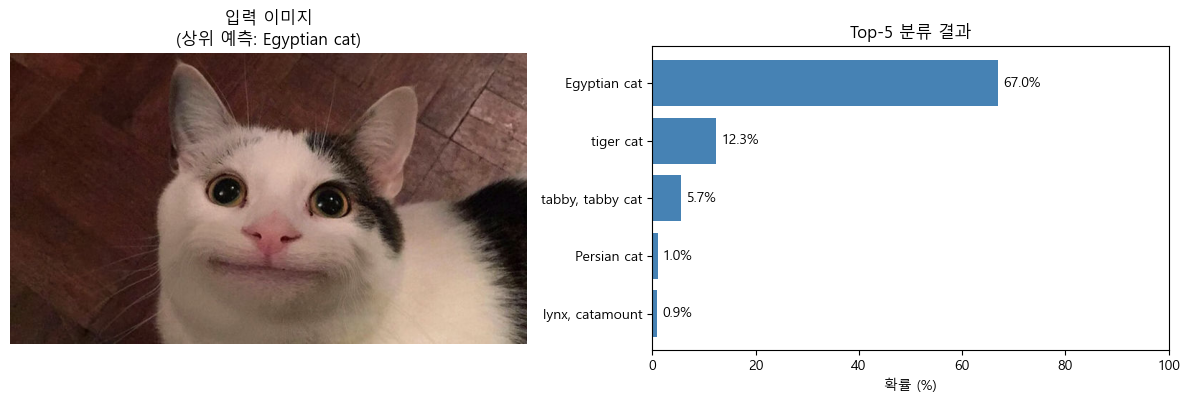

결과: Egyptian cat(67.0%)

현재 이미지: hw/image/3.jpg


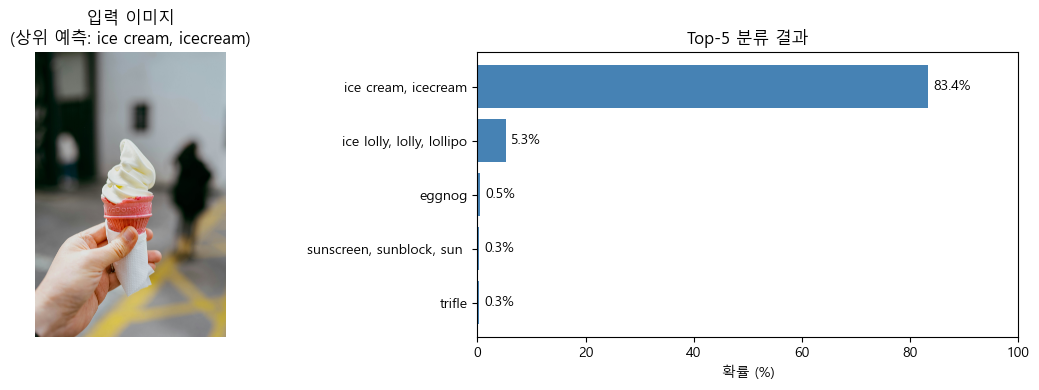

결과: ice cream, icecream(83.4%)

현재 이미지: hw/image/4.jpg


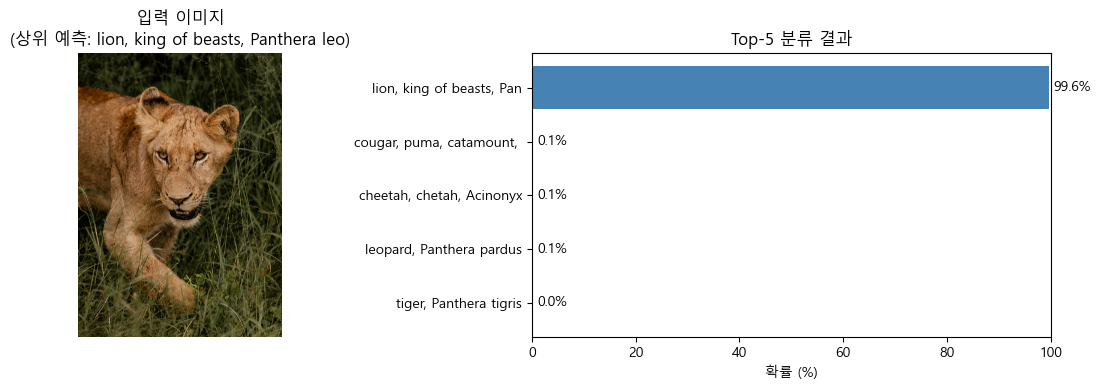

결과: lion, king of beasts, Panthera leo(99.6%)

현재 이미지: hw/image/5.jpg


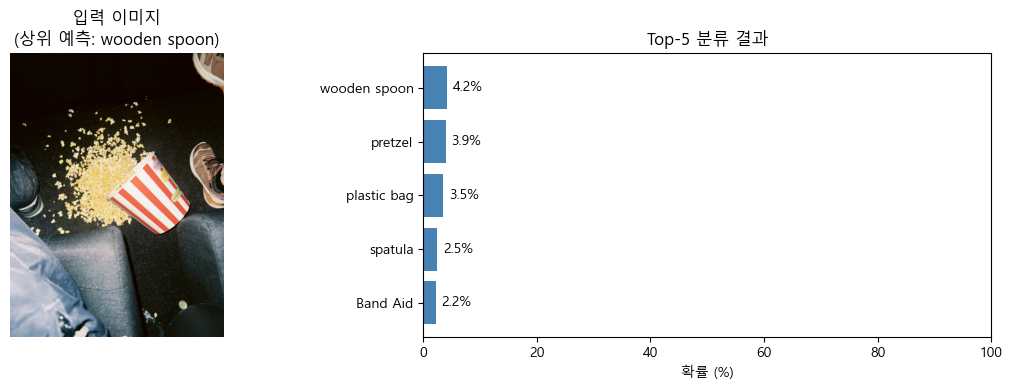

결과: wooden spoon(4.2%)

현재 이미지: hw/image/6.jpg


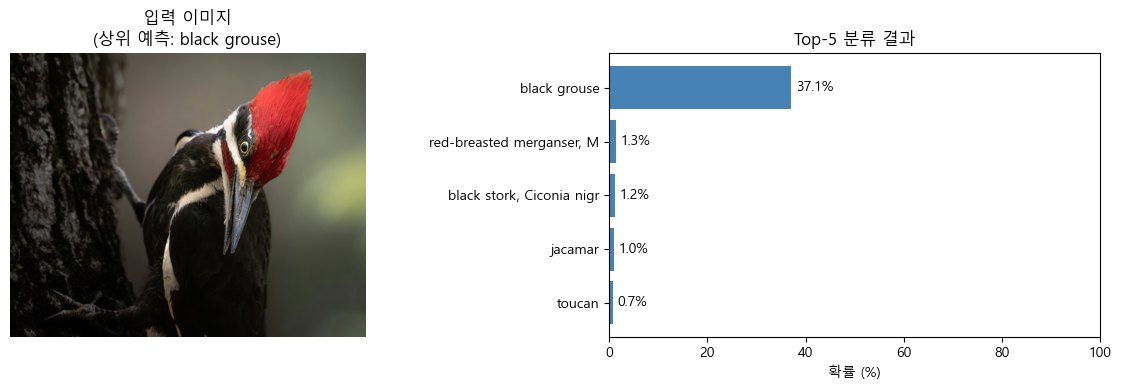

결과: black grouse(37.1%)

현재 이미지: hw/image/7.jpg


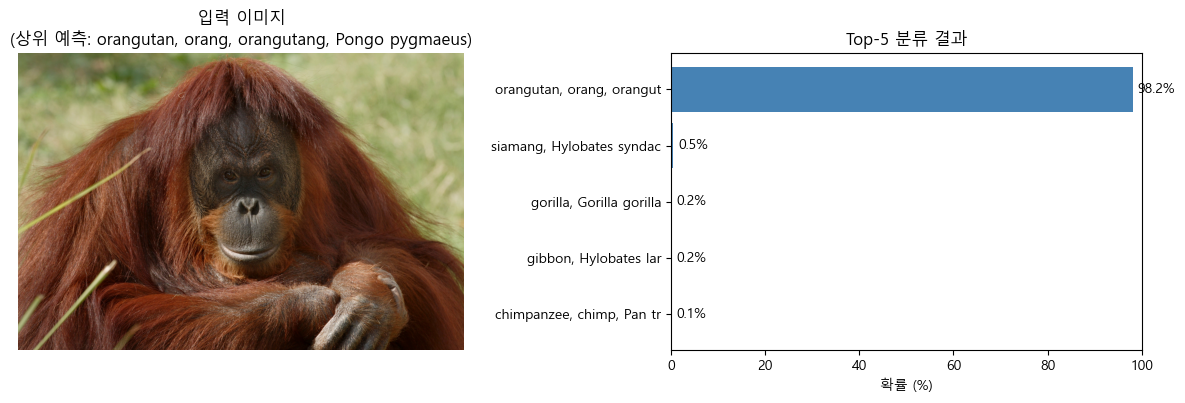

결과: orangutan, orang, orangutang, Pongo pygmaeus(98.2%)

현재 이미지: hw/image/8.jpg


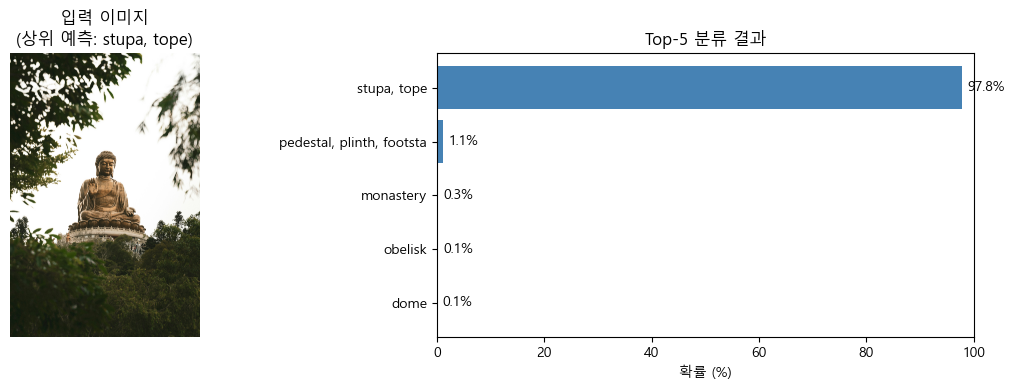

결과: stupa, tope(97.8%)

현재 이미지: hw/image/9.jpg


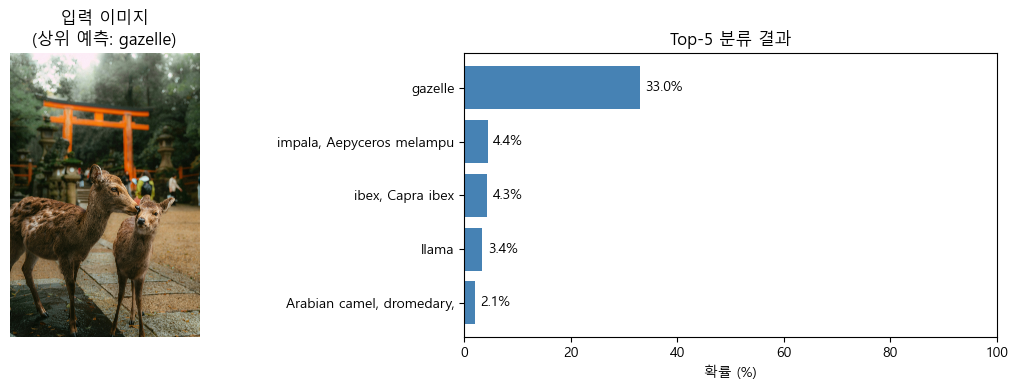

결과: gazelle(33.0%)

현재 이미지: hw/image/10.jpg


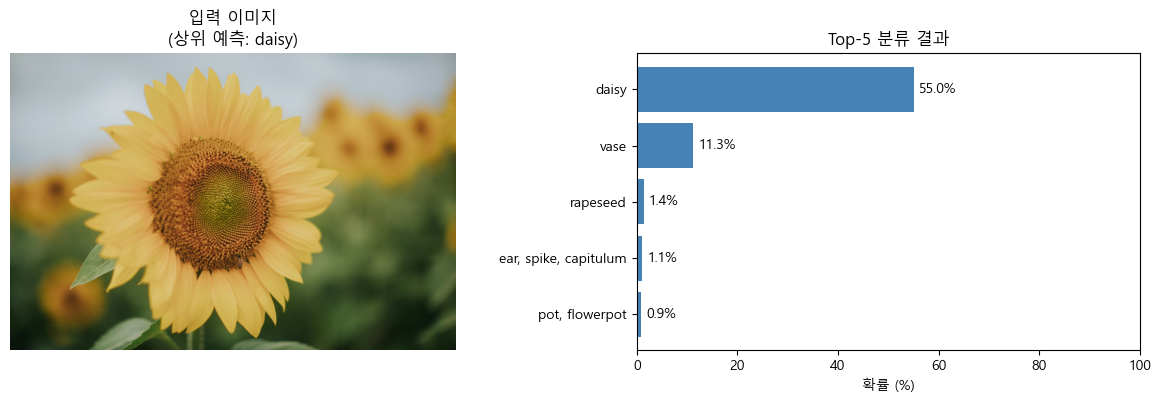

결과: daisy(55.0%)


In [12]:
images = [
    "hw/image/1.jpg",
    "hw/image/2.jpg",
    "hw/image/3.jpg",
    "hw/image/4.jpg",
    "hw/image/5.jpg",
    "hw/image/6.jpg",
    "hw/image/7.jpg",
    "hw/image/8.jpg",
    "hw/image/9.jpg",
    "hw/image/10.jpg"
]

for img in images:
    print(f"\n현재 이미지: {img}")

    result = classify_and_show(img)

    print(f"결과: {result[0]['label']}"
          f"({result[0]['score']*100:.1f}%)")